# ex011_PHT3D_11

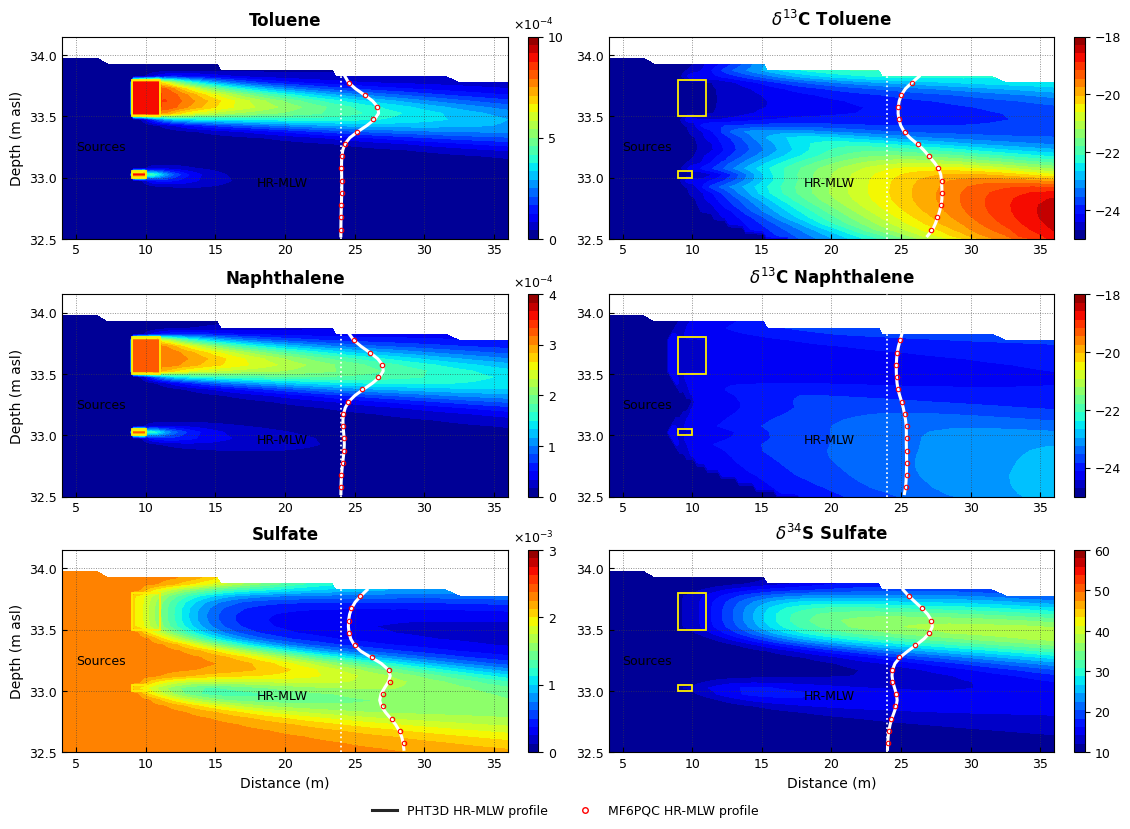

,field RMSE,HR-MLW RMSE,unit,compared cells
quantity,,,,
Toluene,0.655,0.622,% of color range,2557
δ¹³C Toluene,0.057,0.048,‰,2281
Naphthalene,0.636,0.636,% of color range,2557
δ¹³C Naphthalene,0.070,0.024,‰,2249
Sulfate,1.014,1.281,% of color range,2557
δ³⁴S Sulfate,0.292,0.372,‰,2557


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

CASE_DIR = Path.cwd()
INPUT_DIR = CASE_DIR / "input_data"
OUTPUT_DIR = CASE_DIR / "output"
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

NLAY, NROW, NCOL = (58, 1, 99)
DELR = np.array([1.0] * 7 + [0.5] * 2 + [0.25] * 76 + [0.5] * 2 + [1.0] * 12)
TOP = 34.2
BOTM = np.array(
    [34.15 - 0.05 * layer for layer in range(44)]
    + [31.75, 31.5, 31.25, 31.0, 30.5, 30.0]
    + list(np.arange(29.0, 21.0, -1.0))
)
X_CENTERS = np.cumsum(DELR) - 0.5 * DELR
LAYER_TOPS = np.r_[TOP, BOTM[:-1]]
Z_CENTERS = 0.5 * (LAYER_TOPS + BOTM)
X_GRID, Z_GRID = np.meshgrid(X_CENTERS, Z_CENTERS)
results = np.load(OUTPUT_DIR / "results.npy")
result_times = np.load(OUTPUT_DIR / "results_times.npy")
headings = [
    line.strip()
    for line in (OUTPUT_DIR / "results_headings.txt").read_text(encoding="utf-8").splitlines()
    if line.strip()
]
mf6pqc = results.reshape(result_times.size, len(headings), NLAY, NCOL)
archive = np.load(INPUT_DIR / "PHT3D_11_results.npy")
reference = {name: archive[name].copy() for name in archive.dtype.names}
CARBON_STANDARD_RATIO = 0.0112372
SULFUR_STANDARD_RATIO = 0.0001021 / 0.002192 / 1.01


def isotope_delta(light, heavy, standard_ratio, threshold, background_delta):
    total = light + heavy
    delta = np.full(total.shape, background_delta, dtype=float)
    valid = np.isfinite(light) & np.isfinite(heavy) & (total > threshold) & (light > 0.0)
    delta[valid] = (heavy[valid] / light[valid] / standard_ratio - 1.0) * 1000.0
    delta[~np.isfinite(total)] = np.nan
    return delta


def derive_fields(source):
    if source == "mf6pqc":

        def get(name):
            return mf6pqc[:, headings.index(name)]
    elif source == "pht3d":
        get = reference.__getitem__
    else:
        raise ValueError("source must be 'mf6pqc' or 'pht3d'")
    toluene = get("Tolu_l") + get("Tolu_h")
    naphthalene = get("Naph_l") + get("Naph_h")
    sulfate = get("Sulf_l_6") + get("Sulf_h_6")
    return {
        "Toluene": toluene,
        "delta13C Toluene": isotope_delta(
            get("Tolu_l"), get("Tolu_h"), CARBON_STANDARD_RATIO, 1e-08, -25.0
        ),
        "Naphthalene": naphthalene,
        "delta13C Naphthalene": isotope_delta(
            get("Naph_l"), get("Naph_h"), CARBON_STANDARD_RATIO, 1e-08, -25.0
        ),
        "Sulfate": sulfate,
        "delta34S Sulfate": isotope_delta(
            get("Sulf_l_6"), get("Sulf_h_6"), SULFUR_STANDARD_RATIO, 1e-12, 10.0
        ),
    }


mf_fields = derive_fields("mf6pqc")
pht3d_fields = derive_fields("pht3d")
wet_mask = np.isfinite(reference["Sulf_l_6"][-1])
metric_specs = [
    ("Toluene", (0.0, 0.001), 0.001, None),
    ("delta13C Toluene", (-25.0, -18.0), None, pht3d_fields["Toluene"][-1] > 1e-08),
    ("Naphthalene", (0.0, 0.0004), 0.0004, None),
    ("delta13C Naphthalene", (-25.0, -18.0), None, pht3d_fields["Naphthalene"][-1] > 1e-08),
    ("Sulfate", (0.0, 0.003), 0.003, None),
    ("delta34S Sulfate", (10.0, 60.0), None, None),
]
well_column = int(np.argmin(np.abs(X_CENTERS - 24.0)))
figure_mask = wet_mask & (X_GRID >= 4.0) & (X_GRID <= 36.0) & (Z_GRID >= 32.5) & (Z_GRID <= 34.15)
profile_domain = (Z_CENTERS >= 32.5) & (Z_CENTERS <= 34.15) & wet_mask[:, well_column]
rows = []
for name, limits, concentration_scale, extra_mask in metric_specs:
    reproduced = np.clip(mf_fields[name][-1], *limits)
    official = np.clip(pht3d_fields[name][-1], *limits)
    field_mask = figure_mask & np.isfinite(reproduced) & np.isfinite(official)
    profile_mask = profile_domain.copy()
    if extra_mask is not None:
        field_mask &= extra_mask
        profile_mask &= extra_mask[:, well_column]
    field_rmse = float(np.sqrt(np.mean((reproduced[field_mask] - official[field_mask]) ** 2)))
    profile_rmse = float(
        np.sqrt(
            np.mean(
                (reproduced[:, well_column][profile_mask] - official[:, well_column][profile_mask])
                ** 2
            )
        )
    )
    if concentration_scale is not None:
        field_rmse = 100.0 * field_rmse / concentration_scale
        profile_rmse = 100.0 * profile_rmse / concentration_scale
    rows.append(
        {
            "quantity": name.replace("delta13C", "δ¹³C").replace("delta34S", "δ³⁴S"),
            "field RMSE": field_rmse,
            "HR-MLW RMSE": profile_rmse,
            "unit": "‰" if concentration_scale is None else "% of color range",
            "compared cells": int(field_mask.sum()),
        }
    )
metrics = pd.DataFrame(rows).set_index("quantity")
plot_specs = [
    {
        "name": "Toluene",
        "title": "Toluene",
        "scale": 10000.0,
        "limits": (0.0, 10.0),
        "ticks": [0, 5, 10],
        "exponent": "$\\times 10^{-4}$",
    },
    {
        "name": "delta13C Toluene",
        "title": "$\\delta^{13}$C Toluene",
        "scale": 1.0,
        "limits": (-25.0, -18.0),
        "ticks": [-24, -22, -20, -18],
        "exponent": None,
    },
    {
        "name": "Naphthalene",
        "title": "Naphthalene",
        "scale": 10000.0,
        "limits": (0.0, 4.0),
        "ticks": [0, 1, 2, 3, 4],
        "exponent": "$\\times 10^{-4}$",
    },
    {
        "name": "delta13C Naphthalene",
        "title": "$\\delta^{13}$C Naphthalene",
        "scale": 1.0,
        "limits": (-25.0, -18.0),
        "ticks": [-24, -22, -20, -18],
        "exponent": None,
    },
    {
        "name": "Sulfate",
        "title": "Sulfate",
        "scale": 1000.0,
        "limits": (0.0, 3.0),
        "ticks": [0, 1, 2, 3],
        "exponent": "$\\times 10^{-3}$",
    },
    {
        "name": "delta34S Sulfate",
        "title": "$\\delta^{34}$S Sulfate",
        "scale": 1.0,
        "limits": (10.0, 60.0),
        "ticks": [10, 20, 30, 40, 50, 60],
        "exponent": None,
    },
]
PROFILE_X0, PROFILE_WIDTH = (24.0, 6.0)
profile_layers = (Z_CENTERS >= 32.5) & (Z_CENTERS <= 34.0) & wet_mask[:, well_column]
profile_marker_layers = profile_layers & (np.arange(NLAY) % 2 == 0)


def add_case_annotations(ax):
    ax.add_patch(
        Rectangle((9.0, 33.5), 2.0, 0.3, fill=False, edgecolor="#ffef00", linewidth=1.3, zorder=8)
    )
    ax.add_patch(
        Rectangle((9.0, 33.0), 1.0, 0.05, fill=False, edgecolor="#ffef00", linewidth=1.3, zorder=8)
    )
    ax.axvline(PROFILE_X0, color="white", linestyle=":", linewidth=1.25, zorder=7)
    ax.text(5.0, 33.22, "Sources", fontsize=9, color="black", zorder=9)
    ax.text(18.0, 32.93, "HR-MLW", fontsize=9, color="black", zorder=9)


fig, axes = plt.subplots(3, 2, figsize=(11.2, 8.2), constrained_layout=True)
for panel, (ax, spec) in enumerate(zip(axes.flat, plot_specs, strict=False)):
    low, high = spec["limits"]
    reproduced = mf_fields[spec["name"]][-1] * spec["scale"]
    official = pht3d_fields[spec["name"]][-1] * spec["scale"]
    clipped = np.clip(reproduced, low, high).astype(float)
    clipped[~wet_mask] = np.nan
    levels = np.linspace(low, high, 25)
    contour = ax.contourf(X_GRID, Z_GRID, clipped, levels=levels, cmap="jet")
    official_profile = np.clip(official[:, well_column], low, high)
    reproduced_profile = np.clip(reproduced[:, well_column], low, high)
    official_x = PROFILE_X0 + PROFILE_WIDTH * (official_profile - low) / (high - low)
    reproduced_x = PROFILE_X0 + PROFILE_WIDTH * (reproduced_profile - low) / (high - low)
    ax.plot(
        official_x[profile_layers],
        Z_CENTERS[profile_layers],
        color="white",
        linewidth=2.2,
        zorder=9,
    )
    ax.plot(
        reproduced_x[profile_marker_layers],
        Z_CENTERS[profile_marker_layers],
        linestyle="none",
        marker="o",
        markersize=3.2,
        markerfacecolor="none",
        markeredgecolor="red",
        markeredgewidth=0.8,
        zorder=10,
    )
    add_case_annotations(ax)
    ax.set_title(spec["title"], fontsize=12, fontweight="semibold", pad=8)
    ax.set_xlim(4.0, 36.0)
    ax.set_ylim(32.5, 34.15)
    ax.set_xticks(np.arange(5, 36, 5))
    ax.set_yticks([32.5, 33.0, 33.5, 34.0])
    ax.grid(True, color="0.25", linestyle=":", linewidth=0.65, alpha=0.65)
    ax.tick_params(direction="in", labelsize=9)
    if panel // 2 == 2:
        ax.set_xlabel("Distance (m)", fontsize=10)
    if panel % 2 == 0:
        ax.set_ylabel("Depth (m asl)", fontsize=10)
    colorbar = fig.colorbar(contour, ax=ax, ticks=spec["ticks"], fraction=0.05, pad=0.045)
    colorbar.ax.tick_params(labelsize=9)
    if spec["exponent"]:
        colorbar.ax.set_title(spec["exponent"], fontsize=9, pad=5)
legend_handles = [
    Line2D([0], [0], color="0.15", linewidth=2.2, label="PHT3D HR-MLW profile"),
    Line2D(
        [0],
        [0],
        linestyle="none",
        marker="o",
        markersize=4,
        markerfacecolor="none",
        markeredgecolor="red",
        label="MF6PQC HR-MLW profile",
    ),
]
fig.legend(handles=legend_handles, loc="outside lower center", ncol=2, frameon=False, fontsize=9)
plt.show()
display(metrics.style.format({"field RMSE": "{:.3f}", "HR-MLW RMSE": "{:.3f}"}))